In [14]:
!pip install pandas numpy seaborn matplotlib scikit-learn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from pandas.plotting import andrews_curves, parallel_coordinates

# Configure visualization settings
sns.set_theme(context='notebook', style='darkgrid', palette='colorblind', font='sans-serif')
matplotlib.rcParams['figure.figsize'] = [8, 8]
matplotlib.rcParams.update({'font.size': 12})

# ACCESS THE DATASET: This automatically pulls the data from Seaborn's repository
iris = sns.load_dataset('iris')

# Preview to ensure it loaded correctly
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [16]:
# Option A: Load natively via Seaborn (Recommended for this workflow)
iris = sns.load_dataset('iris')

# Option B: Load from Sklearn and convert to DataFrame (For reference)
# iris_data = load_iris()
# iris = pd.DataFrame(data=iris_data['data'], columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
# iris['species'] = iris_data['target']

# Option C: Load from a local CSV (For reference)
# iris = pd.read_csv("Iris_Data.csv")

# Display the first 5 rows
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [17]:
# Check shape and general info
print(f"Dataset shape: {iris.shape}")
iris.info()

# Statistical summary
print("\nStatistical Summary:")
display(iris.describe())

# Check for missing values
print("\nMissing values per column:")
print(iris.isnull().sum())

# Check and drop duplicate rows
dup_count = iris.duplicated().sum()
print(f'\nNumber of duplicated rows: {dup_count}')
if dup_count > 0:
    iris = iris.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")

# Check class distribution
print("\nSpecies distribution:")
print(iris['species'].value_counts())

Dataset shape: (150, 5)
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Number of duplicated rows: 1
Duplicates removed.

Species distribution:
species
setosa        50
versicolor    50
virginica     49
Name: count, dtype: int64


In [18]:
# Create a copy for encoded workflows if needed
df_encoded = iris.copy()

le = LabelEncoder()
df_encoded['species_encoded'] = le.fit_transform(df_encoded['species'])

print("Encoded Species Values Mapping:")
for original, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"{original} -> {encoded}")

Encoded Species Values Mapping:
setosa -> 0
versicolor -> 1
virginica -> 2


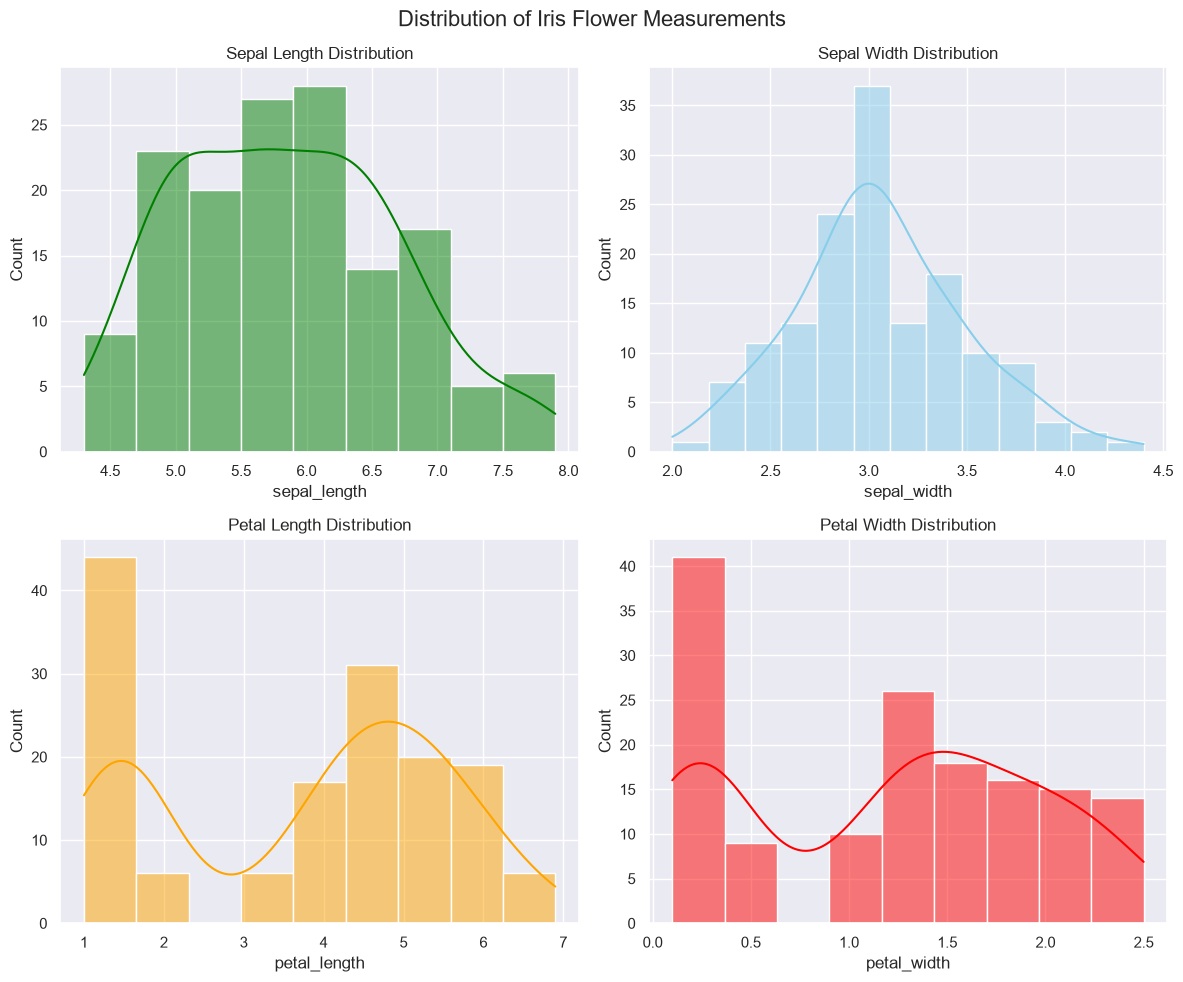

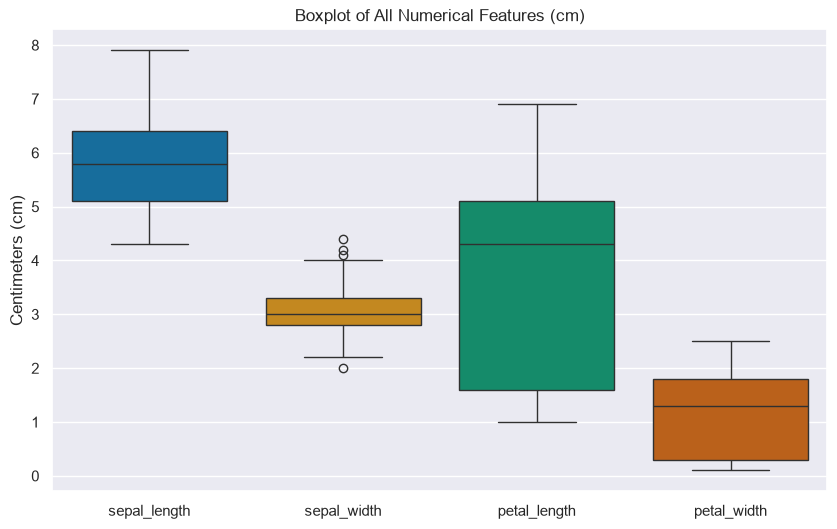

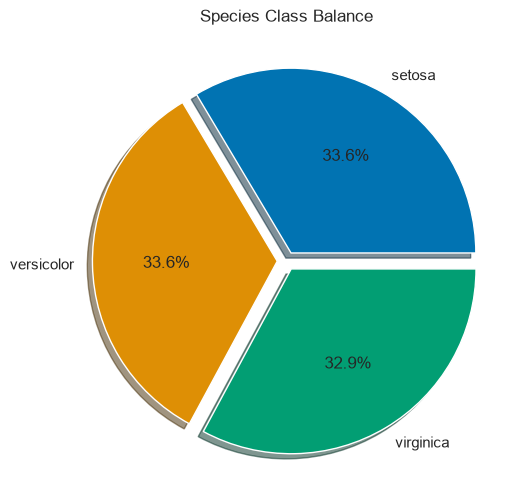

In [19]:
# 5.1 Distribution Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Iris Flower Measurements', fontsize=16)

sns.histplot(iris['sepal_length'], kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title('Sepal Length Distribution')

sns.histplot(iris['sepal_width'], kde=True, ax=axes[0, 1], color='skyblue')
axes[0, 1].set_title('Sepal Width Distribution')

sns.histplot(iris['petal_length'], kde=True, ax=axes[1, 0], color='orange')
axes[1, 0].set_title('Petal Length Distribution')

sns.histplot(iris['petal_width'], kde=True, ax=axes[1, 1], color='red')
axes[1, 1].set_title('Petal Width Distribution')

plt.tight_layout()
plt.show()

# 5.2 Combined Boxplot for Outlier Detection
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris.drop('species', axis=1))
plt.title('Boxplot of All Numerical Features (cm)')
plt.ylabel('Centimeters (cm)')
plt.show()

# 5.3 Categorical Target Distribution (Pie Chart)
plt.figure(figsize=(6, 6))
iris['species'].value_counts().plot.pie(explode=[0.05, 0.05, 0.05], autopct='%1.1f%%', shadow=True)
plt.title("Species Class Balance")
plt.ylabel("")
plt.show()

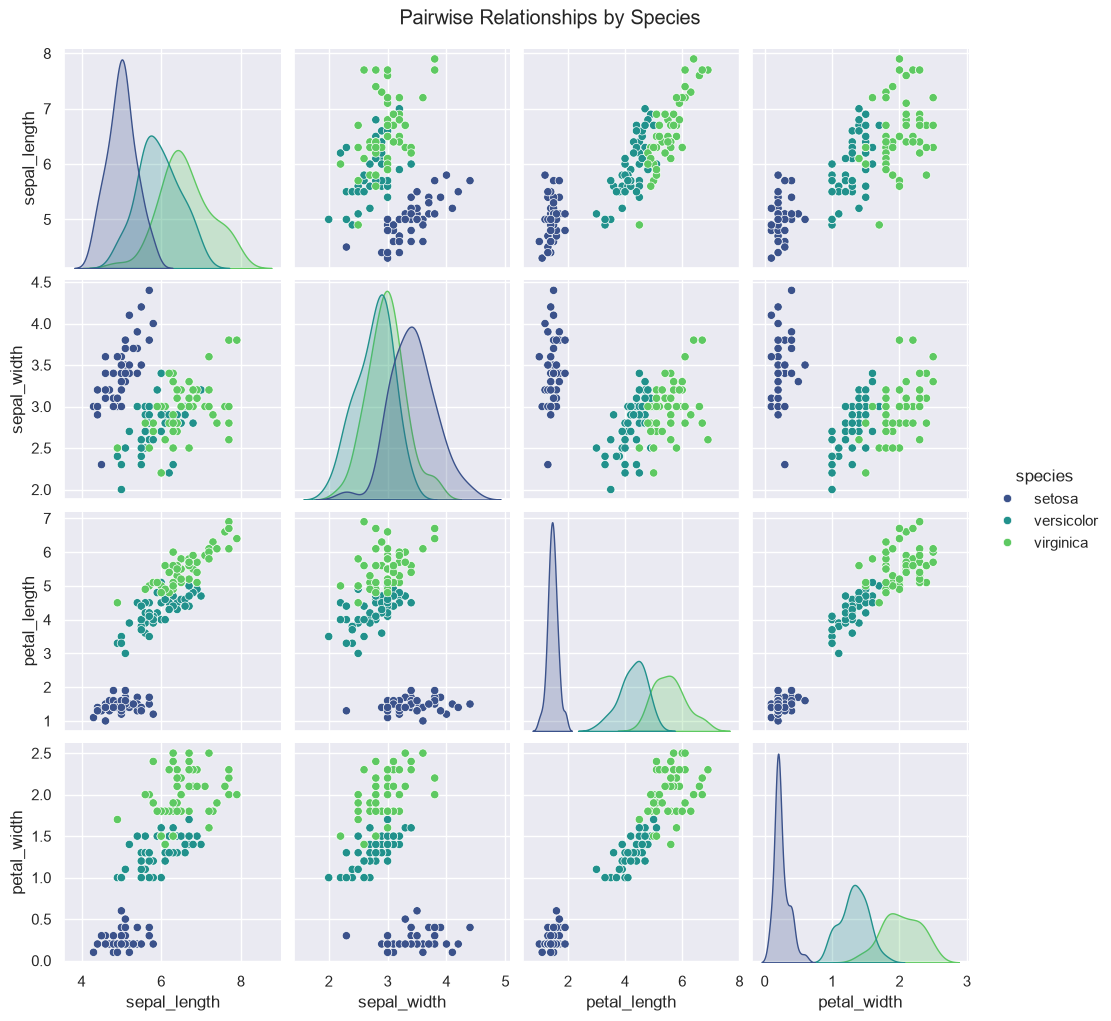

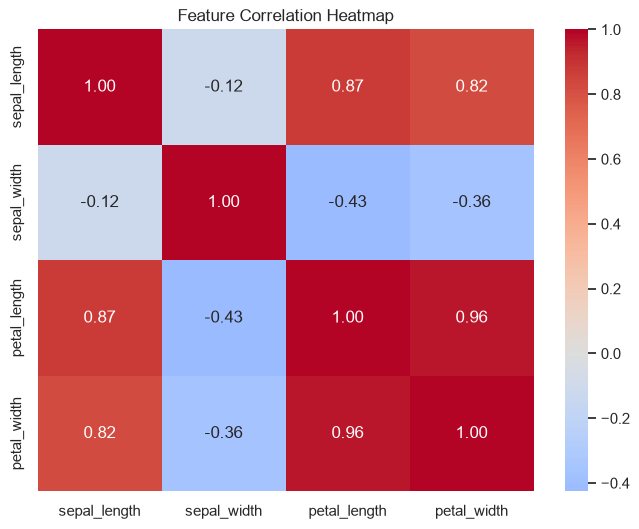

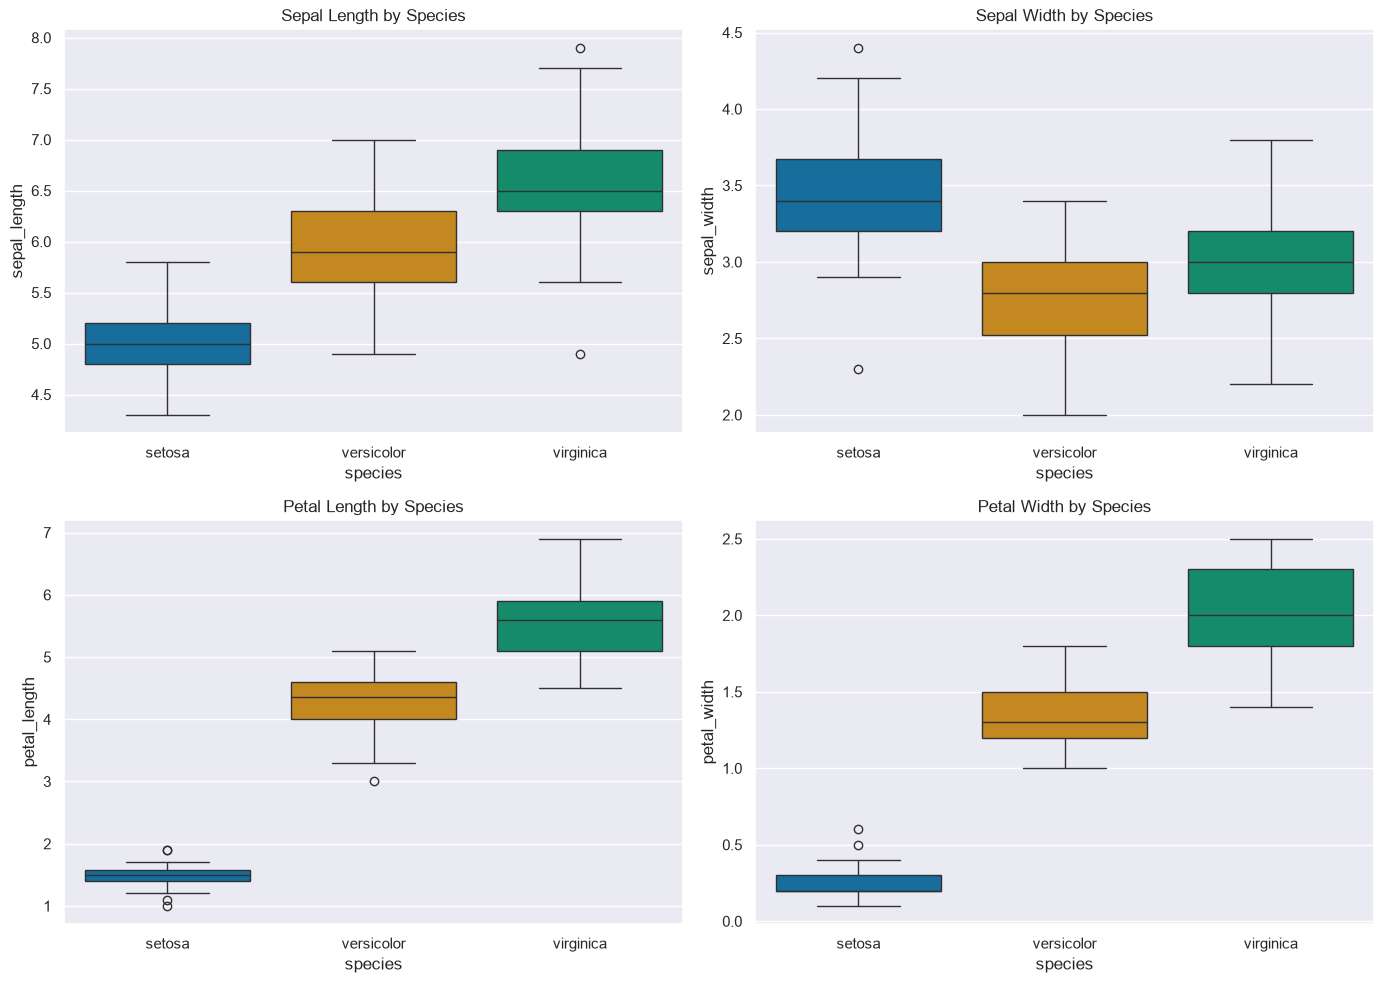

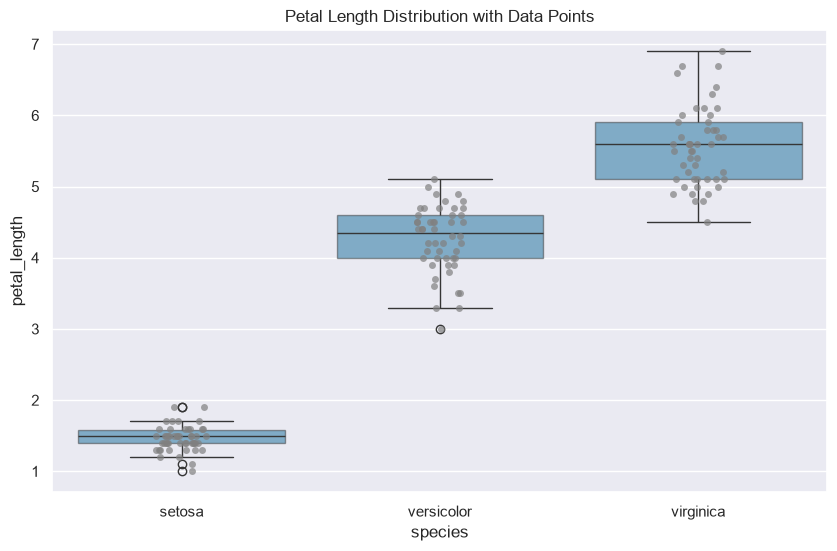

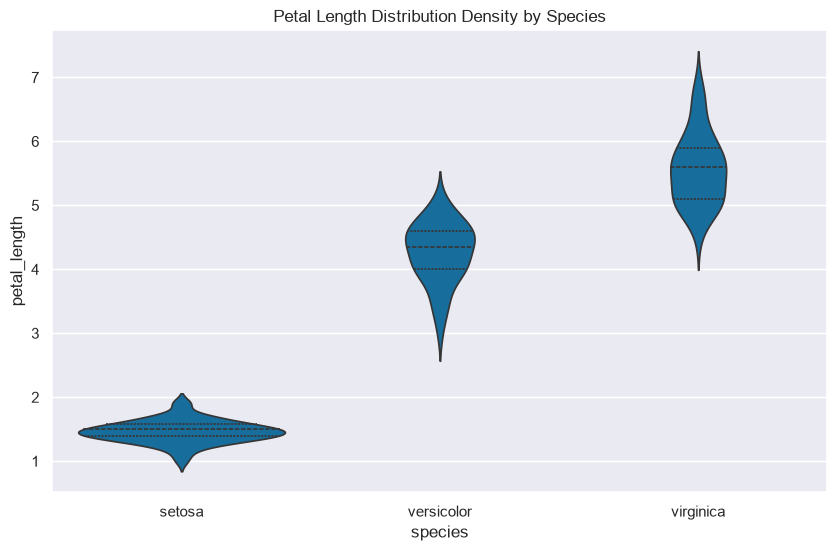

In [20]:
# 6.1 Pairwise Relationship Grid
sns.pairplot(iris, hue='species', palette='viridis', height=2.5)
plt.suptitle('Pairwise Relationships by Species', y=1.02)
plt.show()

# 6.2 Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = iris.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

# 6.3 Feature Distribution Grouped by Species (Boxplots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='species', y='sepal_length', data=iris, ax=axes[0, 0], hue='species', legend=False)
axes[0, 0].set_title('Sepal Length by Species')

sns.boxplot(x='species', y='sepal_width', data=iris, ax=axes[0, 1], hue='species', legend=False)
axes[0, 1].set_title('Sepal Width by Species')

sns.boxplot(x='species', y='petal_length', data=iris, ax=axes[1, 0], hue='species', legend=False)
axes[1, 0].set_title('Petal Length by Species')

sns.boxplot(x='species', y='petal_width', data=iris, ax=axes[1, 1], hue='species', legend=False)
axes[1, 1].set_title('Petal Width by Species')

plt.tight_layout()
plt.show()

# 6.4 Stripplot + Boxplot Hybrid for Deep-Dive
plt.figure(figsize=(10, 6))
sns.boxplot(x="species", y="petal_length", data=iris, boxprops=dict(alpha=0.5))
sns.stripplot(x="species", y="petal_length", data=iris, jitter=True, size=5, color="gray", alpha=0.7)
plt.title('Petal Length Distribution with Data Points')
plt.show()

# 6.5 Violin Plot (Distribution density across categories)
plt.figure(figsize=(10, 6))
sns.violinplot(x='species', y='petal_length', data=iris, inner='quartile')
plt.title('Petal Length Distribution Density by Species')
plt.show()

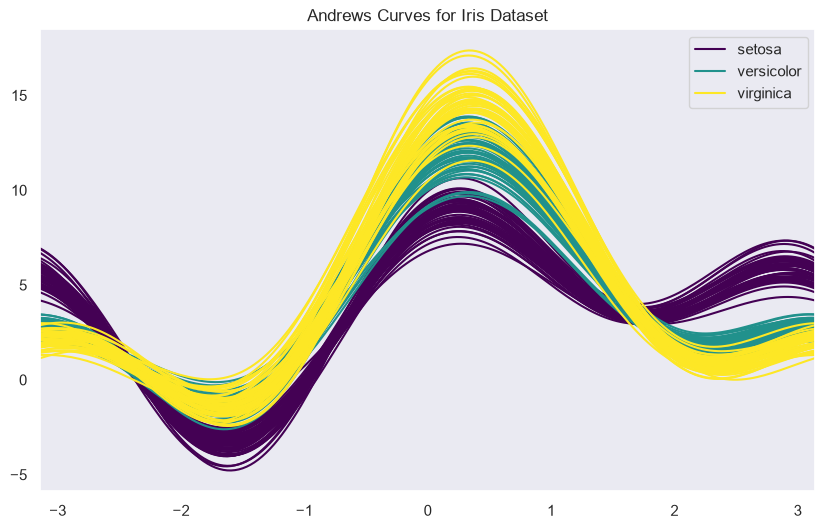

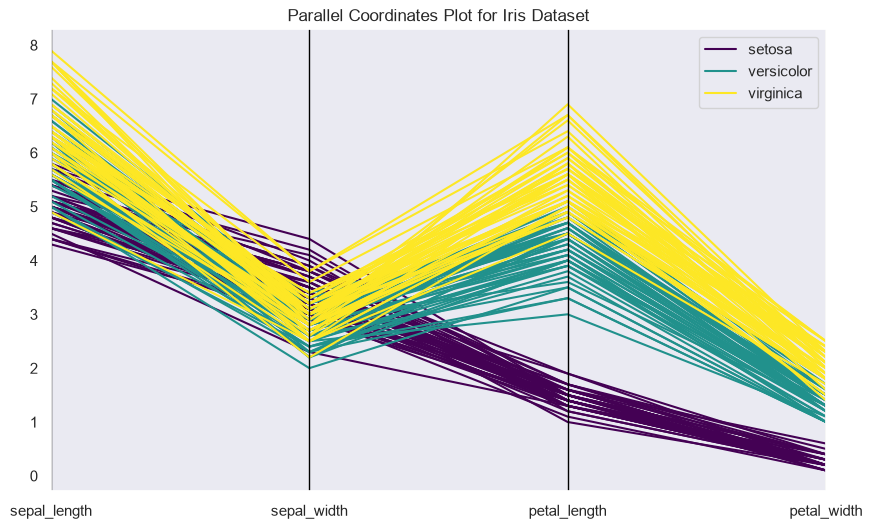

In [21]:
# 7.1 Andrews Curves
plt.figure(figsize=(10, 6))
andrews_curves(iris, 'species', colormap='viridis')
plt.title('Andrews Curves for Iris Dataset')
plt.show()

# 7.2 Parallel Coordinates
plt.figure(figsize=(10, 6))
parallel_coordinates(iris, 'species', colormap='viridis')
plt.title('Parallel Coordinates Plot for Iris Dataset')
plt.show()